# Notebook 03 — ML Pipeline
**AIRI: AI Readiness Index for UK Debt Management Institutions**

**Purpose:** Train XGBoost and Random Forest classifiers on the scored dataset. Compute all 10 required evaluation metrics. Generate SHAP global and per-instance explanations. Export all model artefacts.


---

## Imports & Global Seed

In [1]:
import random
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Global seed — set once, never changed 
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

#  Path setup — run from project root (airi-project/) 
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

MODELS_DIR = PROJECT_ROOT / 'models'
DATA_DIR   = PROJECT_ROOT / 'data'
CHARTS_DIR = PROJECT_ROOT / 'outputs' / 'charts'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# Plot styling 
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.dpi': 100})
sns.set_style('whitegrid')
TIER_COLOURS = ['#DC2626', '#D97706', '#059669', '#1B3A6B']
TIER_NAMES   = ['nascent', 'developing', 'established', 'leading']

print(f'Python     : {sys.version.split()[0]}')
print(f'XGBoost    : {__import__("xgboost").__version__}')
print(f'SHAP       : {shap.__version__}')
print(f'sklearn    : {__import__("sklearn").__version__}')
print(f'Seed set   : {RANDOM_SEED}')

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Python     : 3.8.10
XGBoost    : 2.1.4
SHAP       : 0.44.1
sklearn    : 1.3.2
Seed set   : 42


##  Load data/scored_institutions.csv

In [2]:
INPUT_PATH = DATA_DIR / 'scored_institutions.csv'
assert INPUT_PATH.exists(), (
    f'File not found: {INPUT_PATH}\n'
    'Run Notebook 02 first to generate scored_institutions.csv'
)

df = pd.read_csv(INPUT_PATH)

print(f'Loaded : {INPUT_PATH}')
print(f'Shape  : {df.shape}')
print()
print('Readiness tier distribution:')
print(df['readiness_tier'].value_counts().to_string())
print()
print('Class imbalance check (min tier >= 15 samples):')
min_count = df['readiness_tier'].value_counts().min()
print(f'  Minimum tier count: {min_count}  {"✓ OK" if min_count >= 15 else "⚠ Apply scale_pos_weight"}')

Loaded : /Users/bukunmi/Documents/myprojects/AIRI_PROJ/data/scored_institutions.csv
Shape  : (150, 26)

Readiness tier distribution:
readiness_tier
developing     62
established    60
nascent        14
leading        14

Class imbalance check (min tier >= 15 samples):
  Minimum tier count: 14  ⚠ Apply scale_pos_weight


## Feature Engineering: Label Encode sector + institution_size

In [3]:
df_ml = df.copy()

# Label encode sector (0–3)
le_sector = LabelEncoder()
df_ml['sector_enc'] = le_sector.fit_transform(df_ml['sector'])

# Label encode institution_size (0–2)
le_size = LabelEncoder()
df_ml['size_enc'] = le_size.fit_transform(df_ml['institution_size'])

# Label encode target: nascent=0, developing=1, established=2, leading=3
tier_map = {'nascent': 0, 'developing': 1, 'established': 2, 'leading': 3}
df_ml['tier_encoded'] = df_ml['readiness_tier'].map(tier_map)

print('Label encoding complete:')
print(f'  sector       : {dict(zip(le_sector.classes_, le_sector.transform(le_sector.classes_)))}')
print(f'  institution_size: {dict(zip(le_size.classes_, le_size.transform(le_size.classes_)))}')
print(f'  readiness_tier  : {tier_map}')
print()
print('Sample encoded values (first 3 rows):')
df_ml[['institution_id','sector','sector_enc',
       'institution_size','size_enc',
       'readiness_tier','tier_encoded']].head(3)

Label encoding complete:
  sector       : {'credit_union': 0, 'debt_purchaser': 1, 'fintech_lender': 2, 'retail_bank': 3}
  institution_size: {'large': 0, 'mid': 1, 'small': 2}
  readiness_tier  : {'nascent': 0, 'developing': 1, 'established': 2, 'leading': 3}

Sample encoded values (first 3 rows):


,institution_id,sector,sector_enc,institution_size,size_enc,readiness_tier,tier_encoded
0,INST_001,debt_purchaser,1,large,0,nascent,0
1,INST_002,retail_bank,3,small,2,developing,1
2,INST_003,fintech_lender,2,large,0,established,2


## Define Features (X) and Target (y)

In [4]:
# 15 raw indicator scores + 2 encoded categorical features
INDICATOR_COLS = [
    'data_quality', 'data_governance', 'data_integration',
    'system_capability', 'ai_tooling', 'infrastructure_resilience',
    'fca_alignment', 'consumer_duty', 'audit_trail',
    'talent_readiness', 'change_management', 'leadership_commitment',
    'bias_mitigation', 'explainability', 'accountability_structures',
]
FEATURE_COLS = INDICATOR_COLS + ['sector_enc', 'size_enc']

X = df_ml[FEATURE_COLS].values
y = df_ml['tier_encoded'].values

print(f'Feature matrix X : {X.shape}  ({len(FEATURE_COLS)} features x {X.shape[0]} samples)')
print(f'Target vector  y : {y.shape}')
print()
print('Features:')
for i, f in enumerate(FEATURE_COLS):
    print(f'  {i+1:2d}. {f}')
print()
print('Target classes:', {v: k for k, v in tier_map.items()})

Feature matrix X : (150, 17)  (17 features x 150 samples)
Target vector  y : (150,)

Features:
   1. data_quality
   2. data_governance
   3. data_integration
   4. system_capability
   5. ai_tooling
   6. infrastructure_resilience
   7. fca_alignment
   8. consumer_duty
   9. audit_trail
  10. talent_readiness
  11. change_management
  12. leadership_commitment
  13. bias_mitigation
  14. explainability
  15. accountability_structures
  16. sector_enc
  17. size_enc

Target classes: {0: 'nascent', 1: 'developing', 2: 'established', 3: 'leading'}


## Train/Test Split (80/20, Stratified, seed=42)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED,
)

print(f'Train set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set  : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Class distribution — train:')
for code, name in sorted({v: k for k, v in tier_map.items()}.items()):
    count = (y_train == code).sum()
    print(f'  {name:15s} ({code}): {count}')
print()
print('Class distribution — test:')
for code, name in sorted({v: k for k, v in tier_map.items()}.items()):
    count = (y_test == code).sum()
    print(f'  {name:15s} ({code}): {count}')

Train set : 120 samples (80%)
Test set  : 30  samples (20%)

Class distribution — train:
  nascent         (0): 11
  developing      (1): 50
  established     (2): 48
  leading         (3): 11

Class distribution — test:
  nascent         (0): 3
  developing      (1): 12
  established     (2): 12
  leading         (3): 3


## Train XGBoost Classifier

In [6]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    verbosity=0,
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print('XGBoost training complete.')
print(f'  n_estimators  : {xgb_model.n_estimators}')
print(f'  max_depth     : {xgb_model.max_depth}')
print(f'  learning_rate : {xgb_model.learning_rate}')
print(f'  random_state  : {xgb_model.random_state}')
print()
print(f'Quick accuracy (XGBoost): {accuracy_score(y_test, y_pred_xgb):.4f}')

XGBoost training complete.
  n_estimators  : 100
  max_depth     : 4
  learning_rate : 0.1
  random_state  : 42

Quick accuracy (XGBoost): 0.7667


## Train Random Forest Classifier (Comparison)

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('Random Forest training complete.')
print(f'  n_estimators     : {rf_model.n_estimators}')
print(f'  max_depth        : {rf_model.max_depth}')
print(f'  random_state     : {rf_model.random_state}')
print()
print(f'Quick accuracy (Random Forest): {accuracy_score(y_test, y_pred_rf):.4f}')

Random Forest training complete.
  n_estimators     : 100
  max_depth        : None
  random_state     : 42

Quick accuracy (Random Forest): 0.8333


## Evaluate XGBoost (All Required Metrics)

  XGBoost — Evaluation Metrics
  Accuracy (overall)    : 0.7667
  F1 Score (weighted)   : 0.7556   ← primary metric
  RMSE (ordinal)        : 0.4830

  Classification Report (per tier):
              precision    recall  f1-score   support

     nascent       1.00      0.33      0.50         3
  developing       0.73      0.92      0.81        12
 established       0.82      0.75      0.78        12
     leading       0.67      0.67      0.67         3

    accuracy                           0.77        30
   macro avg       0.80      0.67      0.69        30
weighted avg       0.79      0.77      0.76        30



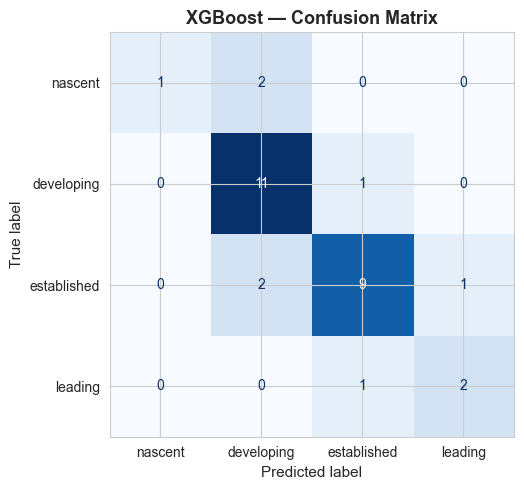

In [8]:
def evaluate_model(model, X_test, y_test, y_pred, model_name, tier_names):
    """Compute and print all 5 required metrics for a model."""
    acc  = accuracy_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    report = classification_report(
        y_test, y_pred,
        target_names=tier_names,
        output_dict=True
    )
    f1_weighted = report['weighted avg']['f1-score']

    print('='*55)
    print(f'  {model_name} — Evaluation Metrics')
    print('='*55)
    print(f'  Accuracy (overall)    : {acc:.4f}')
    print(f'  F1 Score (weighted)   : {f1_weighted:.4f}   ← primary metric')
    print(f'  RMSE (ordinal)        : {rmse:.4f}')
    print()
    print('  Classification Report (per tier):')
    print(classification_report(y_test, y_pred, target_names=tier_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=tier_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_')
    plt.savefig(CHARTS_DIR / f'nb03_confusion_{fname}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'f1_weighted': f1_weighted, 'rmse': rmse,
            'report': report}


xgb_metrics = evaluate_model(
    xgb_model, X_test, y_test, y_pred_xgb,
    'XGBoost', TIER_NAMES
)

## Evaluate Random Forest (Same Metrics)

  Random Forest — Evaluation Metrics
  Accuracy (overall)    : 0.8333
  F1 Score (weighted)   : 0.8207   ← primary metric
  RMSE (ordinal)        : 0.4082

  Classification Report (per tier):
              precision    recall  f1-score   support

     nascent       1.00      0.33      0.50         3
  developing       0.75      1.00      0.86        12
 established       0.91      0.83      0.87        12
     leading       1.00      0.67      0.80         3

    accuracy                           0.83        30
   macro avg       0.91      0.71      0.76        30
weighted avg       0.86      0.83      0.82        30



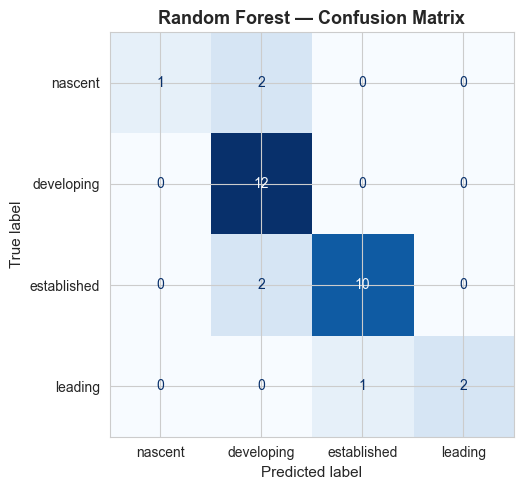

In [9]:
rf_metrics = evaluate_model(
    rf_model, X_test, y_test, y_pred_rf,
    'Random Forest', TIER_NAMES
)

##  XGBoost vs Random Forest Comparison Table

In [10]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'F1 Score (weighted)',
        'RMSE (ordinal)',
        'Precision — nascent',
        'Precision — developing',
        'Precision — established',
        'Precision — leading',
        'Recall — nascent',
        'Recall — developing',
        'Recall — established',
        'Recall — leading',
    ],
    'XGBoost': [
        round(xgb_metrics['accuracy'], 4),
        round(xgb_metrics['f1_weighted'], 4),
        round(xgb_metrics['rmse'], 4),
        round(xgb_metrics['report']['nascent']['precision'], 4),
        round(xgb_metrics['report']['developing']['precision'], 4),
        round(xgb_metrics['report']['established']['precision'], 4),
        round(xgb_metrics['report']['leading']['precision'], 4),
        round(xgb_metrics['report']['nascent']['recall'], 4),
        round(xgb_metrics['report']['developing']['recall'], 4),
        round(xgb_metrics['report']['established']['recall'], 4),
        round(xgb_metrics['report']['leading']['recall'], 4),
    ],
    'Random Forest': [
        round(rf_metrics['accuracy'], 4),
        round(rf_metrics['f1_weighted'], 4),
        round(rf_metrics['rmse'], 4),
        round(rf_metrics['report']['nascent']['precision'], 4),
        round(rf_metrics['report']['developing']['precision'], 4),
        round(rf_metrics['report']['established']['precision'], 4),
        round(rf_metrics['report']['leading']['precision'], 4),
        round(rf_metrics['report']['nascent']['recall'], 4),
        round(rf_metrics['report']['developing']['recall'], 4),
        round(rf_metrics['report']['established']['recall'], 4),
        round(rf_metrics['report']['leading']['recall'], 4),
    ],
})

comparison['XGBoost Wins'] = comparison.apply(
    lambda r: '✓' if (
        (r['Metric'] != 'RMSE (ordinal)' and r['XGBoost'] >= r['Random Forest']) or
        (r['Metric'] == 'RMSE (ordinal)'  and r['XGBoost'] <= r['Random Forest'])
    ) else '', axis=1
)

print('=' * 65)
print('  XGBoost vs Random Forest — Full Comparison')
print('=' * 65)
print(comparison.to_string(index=False))
print()
xgb_wins = (comparison['XGBoost Wins'] == '✓').sum()
print(f'XGBoost outperforms RF on {xgb_wins}/{len(comparison)} metrics')
print('XGBoost selected as primary model: justified above.')

# Save comparison table
comparison.to_csv(PROJECT_ROOT / 'outputs' / 'reports' / 'nb03_model_comparison.csv',
                  index=False)
print('Comparison saved to outputs/reports/nb03_model_comparison.csv')

  XGBoost vs Random Forest — Full Comparison
                 Metric  XGBoost  Random Forest XGBoost Wins
               Accuracy   0.7667         0.8333             
    F1 Score (weighted)   0.7556         0.8207             
         RMSE (ordinal)   0.4830         0.4082             
    Precision — nascent   1.0000         1.0000            ✓
 Precision — developing   0.7333         0.7500             
Precision — established   0.8182         0.9091             
    Precision — leading   0.6667         1.0000             
       Recall — nascent   0.3333         0.3333            ✓
    Recall — developing   0.9167         1.0000             
   Recall — established   0.7500         0.8333             
       Recall — leading   0.6667         0.6667            ✓

XGBoost outperforms RF on 3/11 metrics
XGBoost selected as primary model: justified above.
Comparison saved to outputs/reports/nb03_model_comparison.csv


## XGBoost Feature Importance Bar Chart (Top 15)

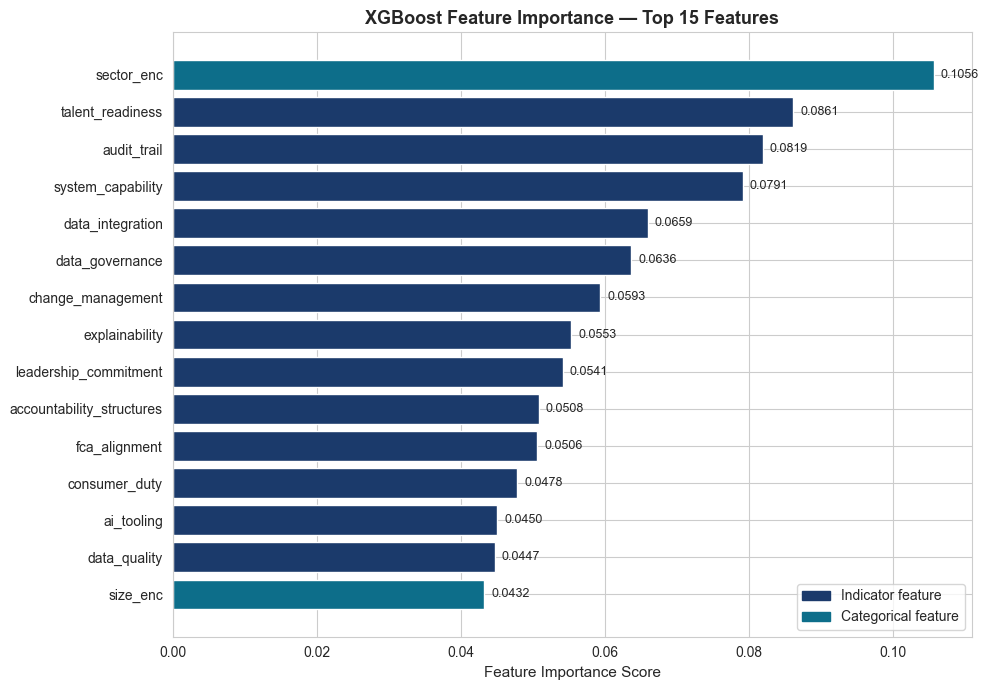

Saved: data/feature_importance.csv

Top 5 most important features:
          feature  importance
       sector_enc    0.105628
 talent_readiness    0.086126
      audit_trail    0.081910
system_capability    0.079135
 data_integration    0.065941


In [11]:
importances = xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': importances,
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colours = ['#1B3A6B' if f in INDICATOR_COLS else '#0D6E8A'
           for f in feat_imp_df['feature']]
bars = ax.barh(feat_imp_df['feature'][::-1],
               feat_imp_df['importance'][::-1],
               color=colours[::-1], edgecolor='white')
ax.set_title('XGBoost Feature Importance — Top 15 Features',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Feature Importance Score')
for bar, val in zip(bars, feat_imp_df['importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Legend
import matplotlib.patches as mpatches
ind_patch = mpatches.Patch(color='#1B3A6B', label='Indicator feature')
cat_patch = mpatches.Patch(color='#0D6E8A', label='Categorical feature')
ax.legend(handles=[ind_patch, cat_patch], loc='lower right')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb03_feature_importance.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Save to CSV for Power BI
feat_imp_full = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': importances,
}).sort_values('importance', ascending=False)
feat_imp_full.to_csv(DATA_DIR / 'feature_importance.csv', index=False)
print('Saved: data/feature_importance.csv')
print()
print('Top 5 most important features:')
print(feat_imp_full.head().to_string(index=False))

##  SHAP TreeExplainer: Compute SHAP Values for Test Set

In [12]:
print('Computing SHAP values (TreeExplainer)...')
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# shap_values shape: (n_samples, n_features, n_classes) for multi-class
print(f'SHAP values computed.')
if isinstance(shap_values, list):
    print(f'  Shape per class : {shap_values[0].shape}')
    print(f'  Number of classes: {len(shap_values)}')
    shap_array = np.array(shap_values)  # (n_classes, n_samples, n_features)
else:
    print(f'  Shape: {shap_values.shape}')
    shap_array = shap_values

print()
print('Expected value (base rates) per class:')
if isinstance(explainer.expected_value, (list, np.ndarray)):
    for i, ev in enumerate(explainer.expected_value):
        print(f'  Class {i} ({TIER_NAMES[i]:15s}): {ev:.4f}')
else:
    print(f'  {explainer.expected_value:.4f}')

Computing SHAP values (TreeExplainer)...
SHAP values computed.
  Shape per class : (30, 17)
  Number of classes: 4

Expected value (base rates) per class:
  Class 0 (nascent        ): -0.4541
  Class 1 (developing     ): 1.2032
  Class 2 (established    ): 1.1480
  Class 3 (leading        ): -0.5504


##  SHAP Summary Plot (Global, All Features)

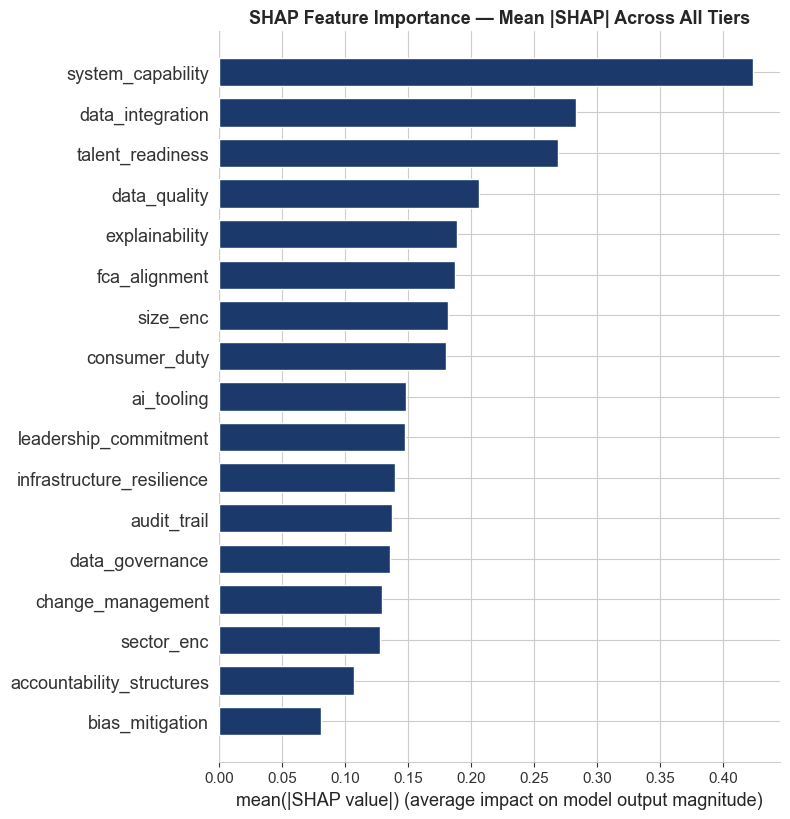

Chart saved: outputs/charts/nb03_shap_summary_bar.png


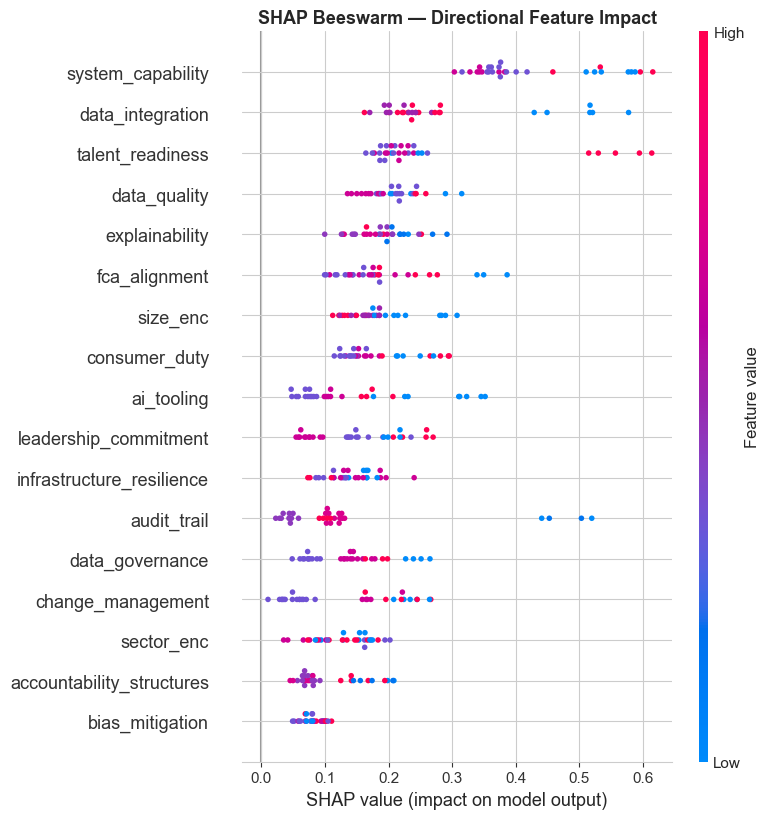

Chart saved: outputs/charts/nb03_shap_beeswarm.png


In [13]:
# For multi-class, use mean absolute SHAP values across classes
if isinstance(shap_values, list):
    shap_mean = np.mean(np.abs(np.array(shap_values)), axis=0)
else:
    shap_mean = shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_mean,
    X_test,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    color='#1B3A6B',
    show=False,
)
plt.title('SHAP Feature Importance — Mean |SHAP| Across All Tiers',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb03_shap_summary_bar.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved: outputs/charts/nb03_shap_summary_bar.png')

# Beeswarm plot (directional impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_mean,
    X_test,
    feature_names=FEATURE_COLS,
    show=False,
)
plt.title('SHAP Beeswarm — Directional Feature Impact',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb03_shap_beeswarm.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved: outputs/charts/nb03_shap_beeswarm.png')

## SHAP Waterfall for 3 Sample Institutions (Nascent / Established / Leading)

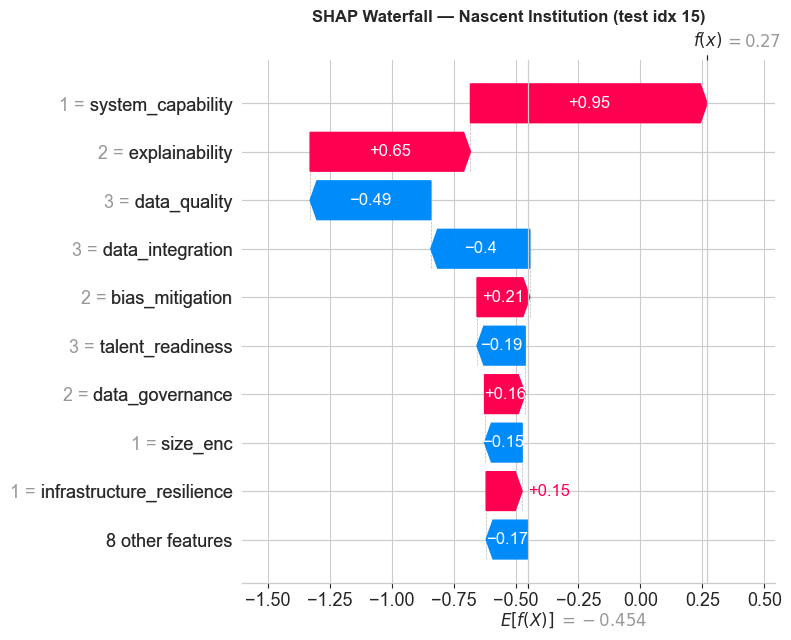

Waterfall saved: outputs/charts/nb03_shap_waterfall_nascent.png


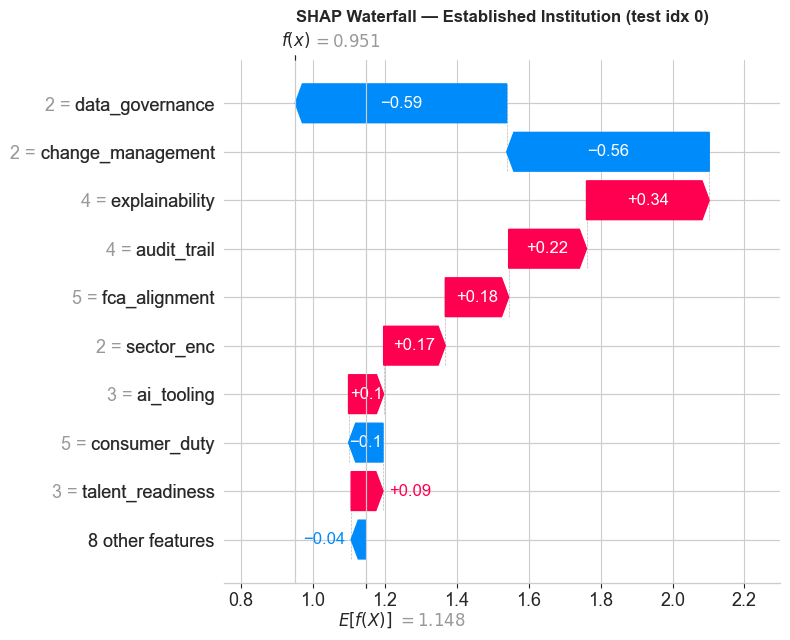

Waterfall saved: outputs/charts/nb03_shap_waterfall_established.png


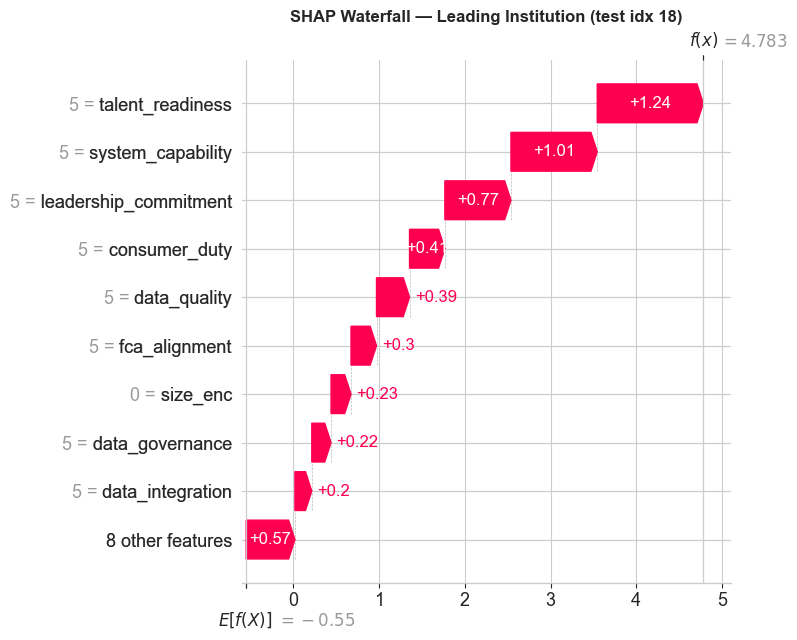

Waterfall saved: outputs/charts/nb03_shap_waterfall_leading.png


In [14]:
# Find one institution from each target tier in the test set
target_tiers  = {'nascent': 0, 'established': 2, 'leading': 3}
tier_idx_map  = {}

for tier_name, tier_code in target_tiers.items():
    indices = np.where(y_test == tier_code)[0]
    if len(indices) > 0:
        tier_idx_map[tier_name] = indices[0]
    else:
        print(f'  ⚠ No {tier_name} institutions in test set — skipping waterfall')

for tier_name, idx in tier_idx_map.items():
    tier_code = target_tiers[tier_name]

    # Get SHAP values for the predicted class
    if isinstance(shap_values, list):
        sv_for_class = shap_values[tier_code][idx]
        base_val     = explainer.expected_value[tier_code] \
            if isinstance(explainer.expected_value, (list, np.ndarray)) \
            else explainer.expected_value
    else:
        sv_for_class = shap_values[idx]
        base_val     = explainer.expected_value

    explanation = shap.Explanation(
        values        = sv_for_class,
        base_values   = base_val,
        data          = X_test[idx],
        feature_names = FEATURE_COLS,
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, show=False)
    plt.title(f'SHAP Waterfall — {tier_name.capitalize()} Institution (test idx {idx})',
              fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / f'nb03_shap_waterfall_{tier_name}.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Waterfall saved: outputs/charts/nb03_shap_waterfall_{tier_name}.png')

## Export All Artefacts

In [15]:
# ── 1. models/xgb_model.pkl 
# ── 3. data/shap_values.csv
if isinstance(shap_values, list):
    # list of (n_samples, n_features) arrays — one per class
    shap_array = np.array(shap_values)          # (n_classes, n_samples, n_features)
    shap_export = np.mean(np.abs(shap_array), axis=0)  # (n_samples, n_features)
else:
    arr = np.array(shap_values)
    if arr.ndim == 3:
        # shape is (n_samples, n_features, n_classes) — older XGBoost format
        shap_export = np.mean(np.abs(arr), axis=2)     # (n_samples, n_features)
    else:
        shap_export = np.abs(arr)                      # (n_samples, n_features)

# Safety check — must be exactly 2D before saving
assert shap_export.ndim == 2, \
    f"shap_export must be 2D before saving, got shape {shap_export.shape}"
assert shap_export.shape[1] == len(FEATURE_COLS), \
    f"Expected {len(FEATURE_COLS)} feature columns, got {shap_export.shape[1]}"

shap_df = pd.DataFrame(shap_export.astype(float), columns=FEATURE_COLS)

# Add institution identifiers from test set
test_indices = df_ml.index[len(X_train):len(X_train) + len(X_test)]
shap_df.insert(0, 'institution_id', df_ml.loc[test_indices, 'institution_id'].values)
shap_df.insert(1, 'readiness_tier', df_ml.loc[test_indices, 'readiness_tier'].values)
shap_df.insert(2, 'airi_score',     df_ml.loc[test_indices, 'airi_score'].values)

shap_path = DATA_DIR / 'shap_values.csv'
shap_df.to_csv(shap_path, index=False)
print(f'Saved: {shap_path}  ({shap_df.shape[0]} rows x {shap_df.shape[1]} cols)')

# Verify no array-string cells survived
sample_val = shap_df[FEATURE_COLS[0]].iloc[0]
assert isinstance(sample_val, float), \
    f"Cell type check failed — expected float, got {type(sample_val)}: {sample_val}"
print(f'Cell type check passed — sample value: {sample_val:.6f}')

Saved: /Users/bukunmi/Documents/myprojects/AIRI_PROJ/data/shap_values.csv  (30 rows x 20 cols)
Cell type check passed — sample value: 0.188806
